In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('heart.csv')

# First look at the data
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (1025, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [2]:
# Column descriptions
columns_info = {
    'age':      'Patient age',
    'sex':      'Sex (1=male, 0=female)',
    'cp':       'Chest pain type (0-3)',
    'trestbps': 'Resting blood pressure (mm Hg)',
    'chol':     'Serum cholesterol (mg/dl)',
    'fbs':      'Fasting blood sugar > 120 mg/dl (1=true, 0=false)',
    'restecg':  'Resting electrocardiographic results (0-2)',
    'thalach':  'Maximum heart rate achieved',
    'exang':    'Exercise induced angina (1=yes, 0=no)',
    'oldpeak':  'ST depression induced by exercise',
    'slope':    'Slope of peak exercise ST segment (0-2)',
    'ca':       'Number of major vessels colored by fluoroscopy (0-3)',
    'thal':     'Thalassemia (0=normal, 1=fixed defect, 2=reversible defect)',
    'target':   'Target variable (1=disease, 0=healthy)'
}

for col, desc in columns_info.items():
    print(f"{col:12} → {desc}")

age          → Patient age
sex          → Sex (1=male, 0=female)
cp           → Chest pain type (0-3)
trestbps     → Resting blood pressure (mm Hg)
chol         → Serum cholesterol (mg/dl)
fbs          → Fasting blood sugar > 120 mg/dl (1=true, 0=false)
restecg      → Resting electrocardiographic results (0-2)
thalach      → Maximum heart rate achieved
exang        → Exercise induced angina (1=yes, 0=no)
oldpeak      → ST depression induced by exercise
slope        → Slope of peak exercise ST segment (0-2)
ca           → Number of major vessels colored by fluoroscopy (0-3)
thal         → Thalassemia (0=normal, 1=fixed defect, 2=reversible defect)
target       → Target variable (1=disease, 0=healthy)


In [3]:
# General dataset information
print("----- GENERAL INFORMATION -----")
df.info()

print("\n----- BASIC STATISTICS -----")
df.describe()

----- GENERAL INFORMATION -----
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

----- BASIC STATISTICS -----


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [4]:
# Checking unique values per column
print("----- UNIQUE VALUES PER COLUMN -----")
for col in df.columns:
    print(f"{col:12} → {df[col].unique()}")

print("\n----- TARGET VARIABLE DISTRIBUTION -----")
print(df['target'].value_counts())
print(f"\nDisease percentage: {df['target'].mean()*100:.1f}%")

----- UNIQUE VALUES PER COLUMN -----
age          → [52 53 70 61 62 58 55 46 54 71 43 34 51 50 60 67 45 63 42 44 56 57 59 64
 65 41 66 38 49 48 29 37 47 68 76 40 39 77 69 35 74]
sex          → [1 0]
cp           → [0 1 2 3]
trestbps     → [125 140 145 148 138 100 114 160 120 122 112 132 118 128 124 106 104 135
 130 136 180 129 150 178 146 117 152 154 170 134 174 144 108 123 110 142
 126 192 115  94 200 165 102 105 155 172 164 156 101]
chol         → [212 203 174 294 248 318 289 249 286 149 341 210 298 204 308 266 244 211
 185 223 208 252 209 307 233 319 256 327 169 131 269 196 231 213 271 263
 229 360 258 330 342 226 228 278 230 283 241 175 188 217 193 245 232 299
 288 197 315 215 164 326 207 177 257 255 187 201 220 268 267 236 303 282
 126 309 186 275 281 206 335 218 254 295 417 260 240 302 192 225 325 235
 274 234 182 167 172 321 300 199 564 157 304 222 184 354 160 247 239 246
 409 293 180 250 221 200 227 243 311 261 242 205 306 219 353 198 394 183
 237 224 265 313 340 259 270 216 26

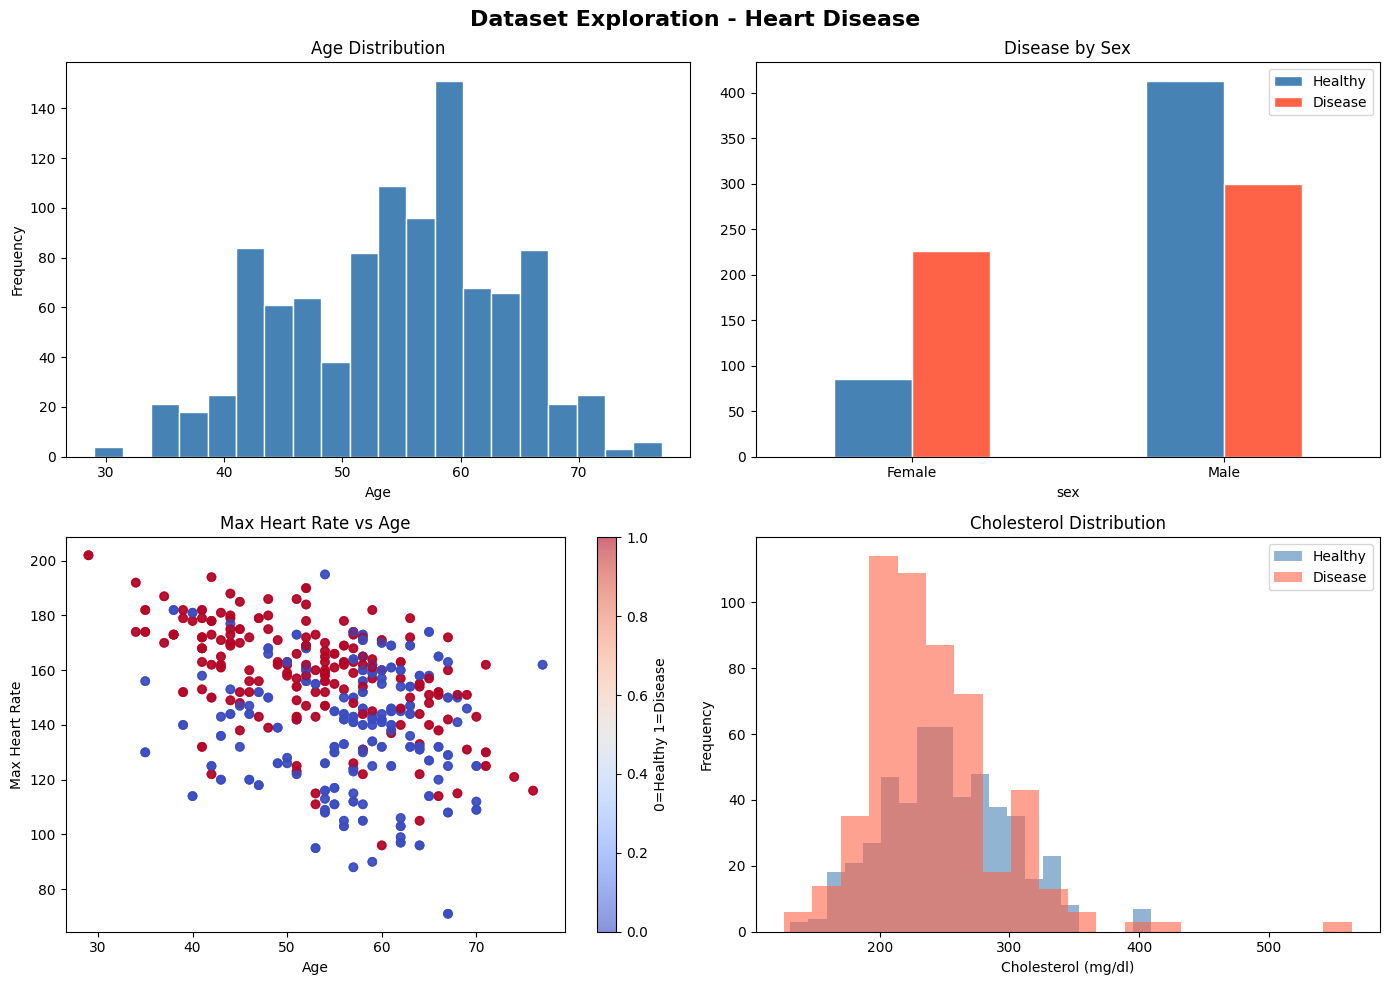

Plot saved as 'inicial_exploration.png'


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dataset Exploration - Heart Disease', fontsize=16, fontweight='bold')

# 1. Age distribution
axes[0,0].hist(df['age'], bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Frequency')

# 2. Disease by sex
sex_target = df.groupby(['sex', 'target']).size().unstack()
sex_target.plot(kind='bar', ax=axes[0,1], color=['steelblue', 'tomato'], edgecolor='white')
axes[0,1].set_title('Disease by Sex')
axes[0,1].set_xticklabels(['Female', 'Male'], rotation=0)
axes[0,1].legend(['Healthy', 'Disease'])

# 3. Max heart rate vs age
scatter = axes[1,0].scatter(df['age'], df['thalach'], 
                            c=df['target'], cmap='coolwarm', alpha=0.6)
axes[1,0].set_title('Max Heart Rate vs Age')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Max Heart Rate')
plt.colorbar(scatter, ax=axes[1,0], label='0=Healthy 1=Disease')

# 4. Cholesterol distribution
axes[1,1].hist(df[df['target']==0]['chol'], bins=20, alpha=0.6, 
               color='steelblue', label='Healthy')
axes[1,1].hist(df[df['target']==1]['chol'], bins=20, alpha=0.6, 
               color='tomato', label='Disease')
axes[1,1].set_title('Cholesterol Distribution')
axes[1,1].set_xlabel('Cholesterol (mg/dl)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('inicial_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as 'inicial_exploration.png'")

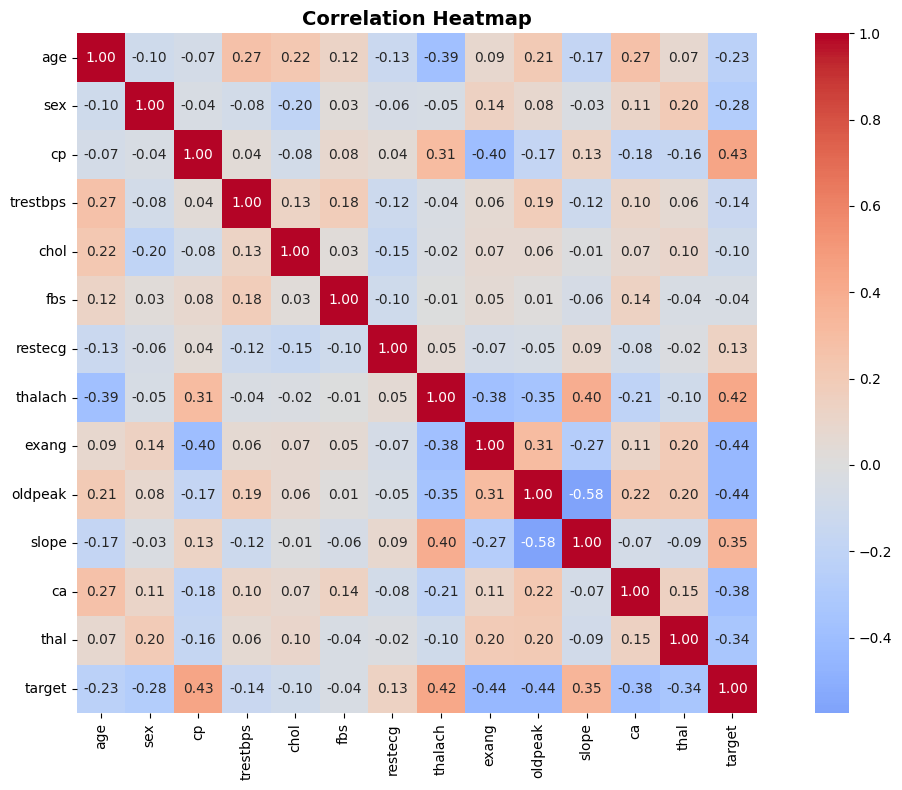

In [6]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, 
            annot=True,        # show numbers
            fmt='.2f',         # 2 decimal places
            cmap='coolwarm',   # blue=negative, red=positive
            center=0,
            square=True)

plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlations.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Separate predictor variables (X) from target variable (y)
X = df.drop('target', axis=1)  # everything except target
y = df['target']               # target only

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42     # for reproducibility
)

print(f"Training samples: {X_train.shape[0]} patients")
print(f"Test samples: {X_test.shape[0]} patients")

# Create and train the model
model = RandomForestClassifier(
    n_estimators=100,   # 100 decision trees
    random_state=42
)
model.fit(X_train, y_train)

print("\n✓ Model trained successfully!")

Training samples: 820 patients
Test samples: 205 patients

✓ Model trained successfully!


Accuracy: 98.54%

----- CLASSIFICATION REPORT -----
              precision    recall  f1-score   support

     Healthy       0.97      1.00      0.99       102
     Disease       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



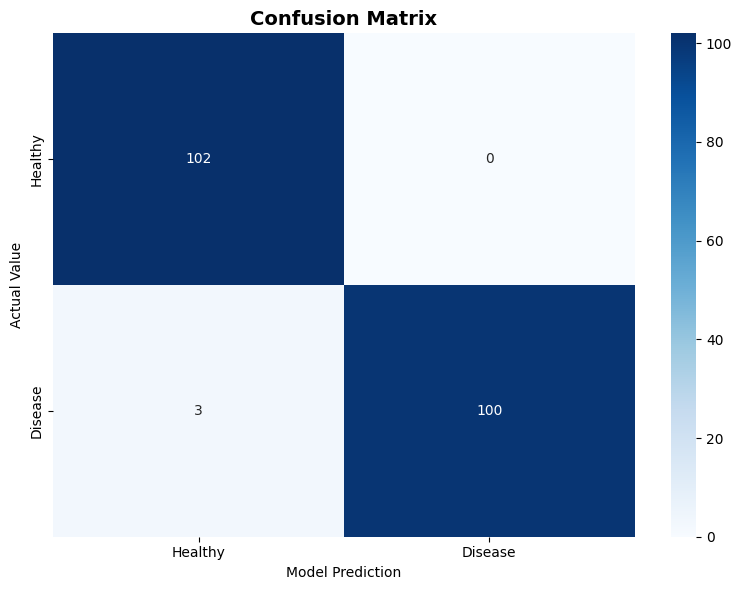

In [8]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

# Detailed classification report
print("\n----- CLASSIFICATION REPORT -----")
print(classification_report(y_test, y_pred, 
                           target_names=['Healthy', 'Disease']))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Disease'],
            yticklabels=['Healthy', 'Disease'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Value')
plt.xlabel('Model Prediction')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

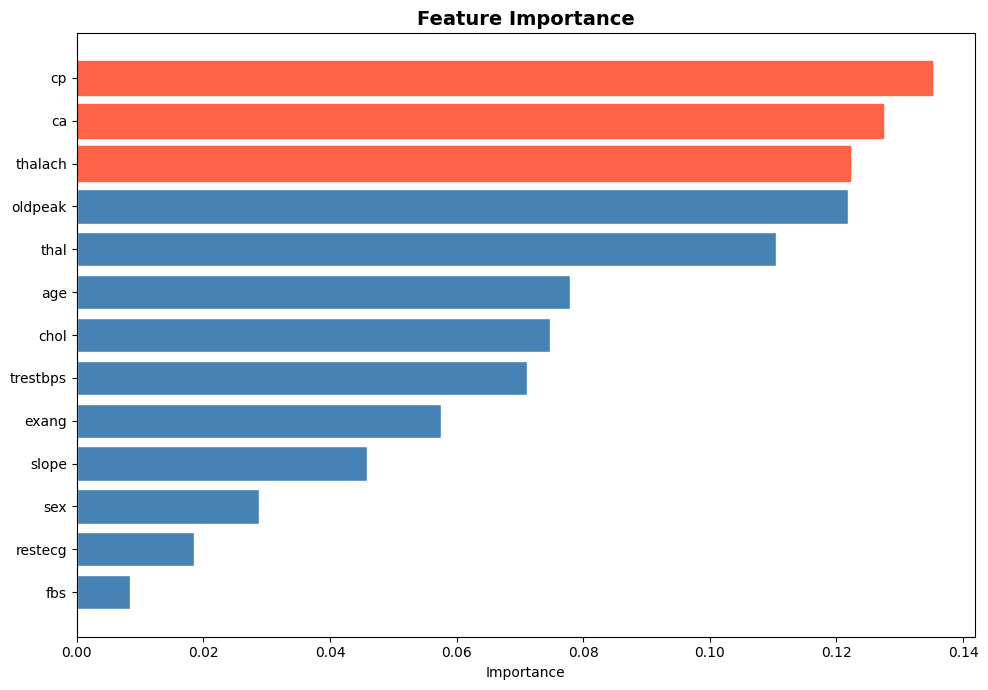

In [9]:
# Feature importance for the model
feature_importance = pd.DataFrame({
    'variable': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 7))
bars = plt.barh(feature_importance['variable'], 
                feature_importance['importance'],
                color='steelblue', edgecolor='white')

# Highlight top 3 most important features
for i, bar in enumerate(bars):
    if i >= len(bars) - 3:
        bar.set_color('tomato')

plt.title('Feature Importance', 
          fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

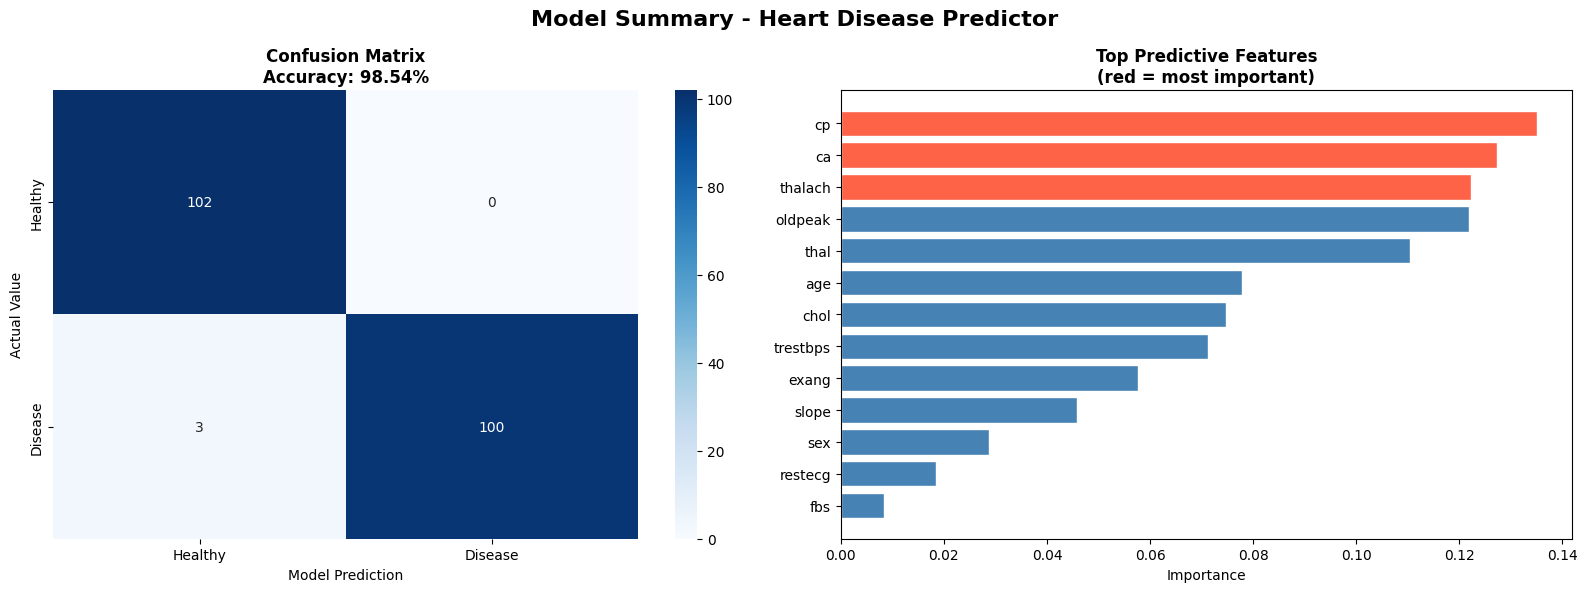

✓ Model summary plot saved!


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Summary - Heart Disease Predictor', 
             fontsize=16, fontweight='bold')

# 1. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Disease'],
            yticklabels=['Healthy', 'Disease'],
            ax=axes[0])
axes[0].set_title(f'Confusion Matrix\nAccuracy: {accuracy:.2%}', 
                  fontweight='bold')
axes[0].set_ylabel('Actual Value')
axes[0].set_xlabel('Model Prediction')

# 2. Feature importance
feature_importance_sorted = feature_importance.sort_values('importance', ascending=True)
colors = ['tomato' if i >= len(feature_importance_sorted) - 3 
          else 'steelblue' for i in range(len(feature_importance_sorted))]
axes[1].barh(feature_importance_sorted['variable'], 
             feature_importance_sorted['importance'],
             color=colors, edgecolor='white')
axes[1].set_title('Top Predictive Features\n(red = most important)', 
                  fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('model_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Model summary plot saved!")